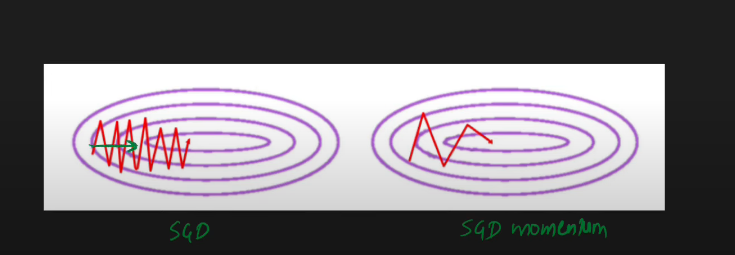



---

## **1. Why Momentum in SGD?**

**Problem with vanilla SGD:**

* Standard **Stochastic Gradient Descent (SGD)** updates parameters by moving in the negative gradient direction.
* If the loss surface is **elongated** (like a narrow valley), SGD can oscillate and take forever to converge.
* Especially when gradients change direction rapidly in some dimensions, you “zigzag” instead of heading straight to the minimum.

**Momentum's idea:**

* Keep a "velocity" term that accumulates the history of past gradients.
* This gives inertia: we keep moving in a direction if it has been consistently good in the past.
* Reduces oscillations and speeds up convergence.

Analogy: Think of a ball rolling down a hill — even if the slope becomes shallow, momentum keeps it rolling.

---

## **2. The Mathematics of SGD with Momentum**

Let:

* $\theta_t$ = parameters at step $t$
* $g_t = \nabla_{\theta} L(\theta_t)$ = gradient at step $t$
* $v_t$ = velocity term (momentum buffer)
* $\eta$ = learning rate
* $\mu$ = momentum coefficient (0 ≤ μ < 1)

**Update rule:**

$$
v_t = \mu v_{t-1} - \eta g_t
$$

$$
\theta_t = \theta_{t-1} + v_t
$$

**Interpretation:**

* $v_t$ is an **exponentially weighted moving average (EWMA)** of past gradients (scaled by $-\eta$).
* The term $\mu v_{t-1}$ retains a fraction of the old velocity.
* The new gradient $g_t$ “nudges” the velocity.

---

### Expanded velocity form:

If we unroll $v_t$:

$$
v_t = -\eta g_t + \mu (-\eta g_{t-1}) + \mu^2 (-\eta g_{t-2}) + \dots
$$

So:

* Recent gradients have higher weight.
* Older gradients contribute less ($\mu^k$ decay).

---

### Comparison to plain SGD:

Plain SGD is just:

$$
\theta_t = \theta_{t-1} - \eta g_t
$$

… with **no smoothing** of the gradient direction.

---

## **3. Numerical Example**

Let’s use:

* $\eta = 0.1$
* $\mu = 0.9$
* Initial $v_0 = 0$
* We have a **1D parameter** θ starting at 5.0
* Loss: $L(\theta) = \theta^2$ (minimum at θ=0)
* Gradient: $g(\theta) = 2\theta$

**Step-by-step:**

**t = 1:**

$$
g_1 = 2(5.0) = 10.0
$$

$$
v_1 = 0.9 \cdot 0 - 0.1 \cdot 10 = -1.0
$$

$$
\theta_1 = 5.0 + (-1.0) = 4.0
$$

**t = 2:**

$$
g_2 = 2(4.0) = 8.0
$$

$$
v_2 = 0.9(-1.0) - 0.1(8.0) = -0.9 - 0.8 = -1.7
$$

$$
\theta_2 = 4.0 + (-1.7) = 2.3
$$

**t = 3:**

$$
g_3 = 2(2.3) = 4.6
$$

$$
v_3 = 0.9(-1.7) - 0.1(4.6) = -1.53 - 0.46 = -1.99
$$

$$
\theta_3 = 2.3 + (-1.99) = 0.31
$$

We are **much closer to zero** in just 3 steps compared to plain SGD, which would move more slowly and oscillate.

---

## **4. Visual Intuition**

* **Without momentum:** steps follow the exact negative gradient — zigzagging in narrow valleys.
* **With momentum:** we "average" gradient directions, so movement aligns more toward the valley floor.

---

## **5. Code Example**

```python
import numpy as np

# Function and gradient
def loss(theta):
    return theta**2

def grad(theta):
    return 2 * theta

# Hyperparameters
eta = 0.1
mu = 0.9
theta = 5.0
v = 0.0

# Training loop
for t in range(1, 6):
    g = grad(theta)
    v = mu * v - eta * g
    theta = theta + v
    print(f"Step {t}: θ = {theta:.4f}, Loss = {loss(theta):.4f}, v = {v:.4f}")
```

---

## **6. Key Points & Theory Insights**

* Momentum **accelerates learning** in relevant directions and **reduces oscillations** in irrelevant ones.
* Works best for **ill-conditioned problems** where gradient magnitudes differ across dimensions.
* Related algorithms:

  * **Nesterov momentum** (look-ahead version)
  * **Adam optimizer** (momentum + adaptive learning rates)
* Theoretically, momentum acts like **a low-pass filter** on the gradient noise.

---




In [1]:
import numpy as np

# Function and gradient
def loss(theta):
    return theta**2

def grad(theta):
    return 2 * theta

# Hyperparameters
eta = 0.1
mu = 0.9
theta = 5.0
v = 0.0

# Training loop
for t in range(1, 6):
    g = grad(theta)
    v = mu * v - eta * g
    theta = theta + v
    print(f"Step {t}: θ = {theta:.4f}, Loss = {loss(theta):.4f}, v = {v:.4f}")


Step 1: θ = 4.0000, Loss = 16.0000, v = -1.0000
Step 2: θ = 2.3000, Loss = 5.2900, v = -1.7000
Step 3: θ = 0.3100, Loss = 0.0961, v = -1.9900
Step 4: θ = -1.5430, Loss = 2.3808, v = -1.8530
Step 5: θ = -2.9021, Loss = 8.4222, v = -1.3591




---

## **1. Motivation: Why Momentum Exists**

Imagine you’re running down a steep winding mountain path:

* **Plain SGD:** You’re blindfolded, taking steps exactly in the direction of steepest slope at each moment. You zigzag left and right a lot, wasting energy.
* **Momentum:** You remember where you’ve been heading for the past few seconds. Instead of overreacting to every twist, you keep a smoothed heading, which:

  * **Speeds you up** along the right direction.
  * **Smooths out noise** from sharp turns.

In ML terms:

* Data noise and curvature cause **oscillations** in gradients.
* Momentum **accumulates directional history** to overcome small slopes and avoid jitter.

---

## **2. The Math (From the Ground Up)**

### 2.1 Vanilla SGD

Given:

* Parameters: $\theta_t$
* Gradient: $g_t = \nabla_\theta L(\theta_t)$
* Learning rate: $\eta$

**Update:**

$$
\theta_{t+1} = \theta_t - \eta g_t
$$

Moves directly opposite to current gradient.

---

### 2.2 Add a Velocity Term

Introduce a **velocity vector** $v_t$ to store accumulated movement:

**Velocity update:**

$$
v_t = \mu v_{t-1} - \eta g_t
$$

**Parameter update:**

$$
\theta_t = \theta_{t-1} + v_t
$$

Where:

* $\mu$ (momentum coefficient) ∈ \[0, 1)

  * Close to 0: little memory.
  * Close to 1: long memory (more smoothing, more inertia).
* $v_0$ = 0 usually.

---

### 2.3 Unrolling the Formula

Unroll $v_t$:

$$
v_t = -\eta g_t - \mu \eta g_{t-1} - \mu^2 \eta g_{t-2} - \dots
$$

It’s an **exponentially weighted moving average (EWMA)** of past gradients:

* Recent gradients have more influence.
* Older ones decay exponentially.

---

### 2.4 Physical Analogy

In physics:

* $v_t$ = velocity of a particle.
* $-\eta g_t$ = force from slope.
* $\mu v_{t-1}$ = inertia from last step.
  This is basically **discrete-time damped motion**.

---

## **3. Intuition in 2D Loss Surfaces**

Imagine an elongated bowl-shaped loss:

* **Plain SGD**: Oscillates across the narrow walls while slowly descending.
* **Momentum**: The velocity term dampens side-to-side oscillations and speeds descent along the valley floor.

---

## **4. Momentum Variants**

### 4.1 Classical Momentum (Polyak, 1964)

The version we’ve described so far.

### 4.2 Nesterov Accelerated Gradient (NAG)

Instead of computing gradient at current position, compute it at **look-ahead position**:

$$
v_t = \mu v_{t-1} - \eta \nabla_\theta L(\theta_{t-1} + \mu v_{t-1})
$$

Helps anticipate future position for a more accurate correction.

---

## **5. Numerical Example**

Let’s compare **SGD vs Momentum** for:

$$
L(\theta) = \theta^2
$$

* $\eta = 0.1$
* $\mu = 0.9$
* Start: $\theta_0 = 5$

| t | Gradient g | v (momentum) | θ (momentum) | θ (SGD) |
| - | ---------- | ------------ | ------------ | ------- |
| 0 | 10.0       | 0.0          | 5.0000       | 5.0000  |
| 1 | 10.0       | -1.0         | 4.0000       | 4.0000  |
| 2 | 8.0        | -1.7         | 2.3000       | 3.2000  |
| 3 | 4.6        | -1.99        | 0.3100       | 2.5600  |
| 4 | 0.62       | -1.8718      | -1.5618      | 2.0480  |

Momentum overshoots but converges faster.

---

## **6. Python Implementation & Visualization**

Let’s see both methods on a **ravine-like loss surface**.

```python
import numpy as np
import matplotlib.pyplot as plt

# Synthetic loss surface: elongated bowl
def loss(theta):
    return 0.5 * (theta[0]**2 + 10*theta[1]**2)

def grad(theta):
    return np.array([theta[0], 10*theta[1]])

# Params
eta = 0.1
mu = 0.9
steps = 30

# Init
theta_sgd = np.array([4.0, 4.0])
theta_mom = np.array([4.0, 4.0])
v = np.zeros(2)

sgd_path = [theta_sgd.copy()]
mom_path = [theta_mom.copy()]

for _ in range(steps):
    # SGD
    theta_sgd -= eta * grad(theta_sgd)
    sgd_path.append(theta_sgd.copy())

    # Momentum
    g = grad(theta_mom)
    v = mu * v - eta * g
    theta_mom += v
    mom_path.append(theta_mom.copy())

sgd_path = np.array(sgd_path)
mom_path = np.array(mom_path)

# Plot
plt.figure(figsize=(6,6))
plt.plot(sgd_path[:,0], sgd_path[:,1], 'o-', label='SGD')
plt.plot(mom_path[:,0], mom_path[:,1], 'o-', label='Momentum')
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.legend()
plt.title("SGD vs SGD with Momentum")
plt.grid(True)
plt.show()
```

This plot will show:

* **SGD:** Zigzags across the valley.
* **Momentum:** Quickly aligns with the valley and heads to the minimum.

---

## **7. Practical Tips**

* **Typical μ values:** 0.9 (classical), 0.95+ for large datasets.
* **Too high μ**: Can cause overshooting and instability.
* **Learning rate tuning**: Momentum allows slightly larger learning rates than vanilla SGD.
* Works well with **batch normalization**, but can be redundant with some adaptive optimizers (Adam already has momentum-like behavior).

---

## **8. Theory Connection**

* Momentum is essentially a **first-order method with memory**.
* Closely related to **Polyak’s heavy ball method** in convex optimization.
* Convergence theory: For convex smooth functions, momentum can improve asymptotic convergence rate from $O(1/t)$ to $O(1/t^2)$ in some settings (especially with Nesterov).

---



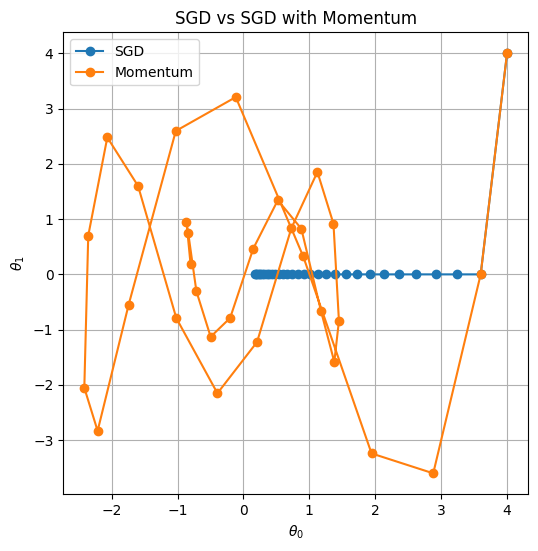

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic loss surface: elongated bowl
def loss(theta):
    return 0.5 * (theta[0]**2 + 10*theta[1]**2)

def grad(theta):
    return np.array([theta[0], 10*theta[1]])

# Params
eta = 0.1
mu = 0.9
steps = 30

# Init
theta_sgd = np.array([4.0, 4.0])
theta_mom = np.array([4.0, 4.0])
v = np.zeros(2)

sgd_path = [theta_sgd.copy()]
mom_path = [theta_mom.copy()]

for _ in range(steps):
    # SGD
    theta_sgd -= eta * grad(theta_sgd)
    sgd_path.append(theta_sgd.copy())

    # Momentum
    g = grad(theta_mom)
    v = mu * v - eta * g
    theta_mom += v
    mom_path.append(theta_mom.copy())

sgd_path = np.array(sgd_path)
mom_path = np.array(mom_path)

# Plot
plt.figure(figsize=(6,6))
plt.plot(sgd_path[:,0], sgd_path[:,1], 'o-', label='SGD')
plt.plot(mom_path[:,0], mom_path[:,1], 'o-', label='Momentum')
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.legend()
plt.title("SGD vs SGD with Momentum")
plt.grid(True)
plt.show()



---

## **1. Update Rule Reminder**

Momentum SGD:

$$
v_t = \beta v_{t-1} - \eta g_t
$$

$$
\theta_t = \theta_{t-1} + v_t
$$

---

## **2. If β = 1**

The velocity update becomes:

$$
v_t = v_{t-1} - \eta g_t
$$

This means:

* **No decay** of old velocity.
* Every past gradient is remembered **forever** (no exponential forgetting).
* Velocity becomes a sum of all past gradients (scaled by $-\eta$).

---

### **3. Mathematical Consequence**

Unrolling for β=1:

$$
v_t = v_0 - \eta \sum_{k=1}^t g_k
$$

If gradients don’t sum to zero exactly, $v_t$ keeps **growing** in magnitude.

* This can lead to **divergence** because there’s no damping.
* In practice, β=1 makes the optimizer unstable unless η is extremely small.

---

### **4. Intuition**

Imagine pushing a ball down a hill with **no friction**:

* Every push (gradient) adds speed.
* The ball never slows down.
* If the hill is curved (non-linear loss), you overshoot and oscillate wildly.

---

### **5. Practical Rule**

* Always keep $0 \leq \beta < 1$ for stability.
* **β close to 1 (like 0.999)** is sometimes used in Adam for bias correction, but that’s in a different context — there, learning rates are adapted per parameter, which helps control the instability.
* In plain SGD with Momentum, β=1 is **almost always unstable** unless the learning rate is near zero.

---






---

## **Top Interview Questions & Answers: SGD with Momentum**

---

### **1. What is SGD with Momentum?**

**Answer:**
SGD with Momentum is an optimization method that improves standard Stochastic Gradient Descent by adding a “velocity” term. This velocity remembers the past updates and combines them with the current gradient. As a result, the algorithm moves more smoothly and often converges faster, especially on surfaces with narrow valleys.

---

### **2. Why do we use momentum in SGD?**

**Answer:**
Momentum helps solve two main problems with vanilla SGD:

1. **Slow convergence** in directions with small but consistent gradients.
2. **Oscillations** in directions where gradients change sign often.
   By accumulating gradients over time, momentum keeps the optimizer moving in the right direction and reduces zigzagging.

---

### **3. How does the update rule for SGD with Momentum work?**

**Answer:**
It uses two equations:

1. Update the velocity:

$$
v_t = \mu v_{t-1} - \eta g_t
$$

2. Update the parameters:

$$
\theta_t = \theta_{t-1} + v_t
$$

Here, $\mu$ is the momentum coefficient (0 to 1), $\eta$ is the learning rate, and $g_t$ is the gradient.

---

### **4. What is the role of the momentum coefficient (μ)?**

**Answer:**
The momentum coefficient controls how much of the previous velocity we keep.

* A small μ (e.g., 0.5) gives short memory.
* A large μ (e.g., 0.9 or 0.99) keeps long-term direction and speeds up movement along consistent slopes.
  However, if μ is too high, it can cause overshooting.

---

### **5. How is momentum different from Nesterov Accelerated Gradient (NAG)?**

**Answer:**
In classical momentum, we calculate the gradient at the current position.
In NAG, we calculate the gradient at the **look-ahead position** (current position + momentum step).
This gives NAG more accurate updates and often better performance.

---

### **6. Can momentum replace learning rate tuning?**

**Answer:**
No. Momentum works best when combined with a well-chosen learning rate. In fact, you can often use a slightly higher learning rate with momentum than with vanilla SGD, but you still need to tune it.

---

### **7. Does momentum help with noisy gradients?**

**Answer:**
Yes. Momentum acts like a low-pass filter on gradients, meaning it smooths out high-frequency noise. This is especially useful in mini-batch training where gradients are naturally noisy.

---

### **8. When would you not use momentum?**

**Answer:**
If you are already using an optimizer with built-in momentum-like behavior (e.g., Adam or RMSprop with momentum), adding classical momentum is usually unnecessary. Also, for extremely unstable training, momentum can make divergence worse if not tuned carefully.

---

### **9. What are typical values for μ and η?**

**Answer:**

* **μ:** 0.9 is standard; 0.95–0.99 for large datasets or when gradients are stable.
* **η:** Depends on problem; common starting point is 0.01–0.1 for SGD with momentum.

---

### **10. Can you give a simple analogy for momentum?**

**Answer:**
Think of pushing a heavy shopping cart down a hill. Even if you stop pushing, it keeps moving because of momentum. Similarly, in optimization, momentum keeps the parameters moving in the same general direction, even when the gradient becomes small or changes slightly.

---



| Drawback                                        | Explanation                                                                                                                 |
| ----------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------- |
| **Overshooting**                                | High β (momentum coefficient) can push parameters past the minimum, causing oscillations or divergence.                     |
| **Extra hyperparameter**                        | You must tune β along with learning rate η, and they interact.                                                              |
| **Slower response to gradient changes**         | Because momentum averages past gradients, it reacts less quickly to sudden shifts (problem if loss landscape changes fast). |
| **Can amplify noise**                           | If gradient noise is correlated over time, momentum can magnify it instead of canceling it.                                 |
| **Not always helpful with adaptive optimizers** | Adam, RMSProp already include momentum-like terms, so adding classical momentum may not help much.                          |
